# DA4 -  Visualizations practice

### Types of visualization

We can distinguish between univariate and bivariate plots. Univariate plots visualize one variable, while bivariate plots show the relation between variables.

Looking at seaborn options, we can distinguish
* Relational plots - that show a relation between two continous variables
* Distribution plots - that show distributions of continous variables
* Categorical plots - that show distributions of categorical variables. 

See seaborn's own [function overview diagram](https://seaborn.pydata.org/tutorial/function_overview.html) for the full picture of which function belongs to which category (e.g. `scatterplot`/`lineplot` under Relational, `histplot`/`kdeplot` under Distribution, `countplot`/`barplot`/`violinplot` under Categorical).

###  Setup: install,import packages and load dataset

In [18]:
# Before starting: Install seaborn package
# For installing seaborn
# !pip install seaborn

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Make plots show up in the notebook
# %matplotlib inline

In [3]:
# Seaborn has many built in dataset for practicing 
# You can see available datasets using the following (before picking one to load)
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [6]:
# Load Seaborn's built-in tips dataset
# Lets use the dataset 'tips'
df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


#### Quick check: what columns do we have?

In [7]:
# Options to see the columns
df.info()          # columns + dtypes + non-null counts + memory usage
# df.columns        # just the column names
# df.dtypes         # column names + data types
# list(df.columns)  # columns as a plain list
# df.head()         # preview first rows (all columns)

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


#### Seaborn “grammar”
Every plot needs:
- **data**: which dataframe you want to plot
- **x, y**: what will be plotted on the x-axis and y-axis

Optional (often useful):
- **hue**: group by color
- **col**: split into subplots (facets)
- **style**: different markers/linestyles per group


## Task 1 -  Distribution plot (univariate)

**Goal:** Visualize the distribution of a continuous variable.  
**Task:** Use the `total_bill` column to see its distribution.  
**Hint:** Use `sns.displot()` or `sns.histplot()` and pass the column of interest.


In [8]:
# Quick doc check: `sns.displot()`
# Before jumping into the task, let's peek at the function's docstring to see what arguments it accepts.
# help(sns.displot)
# Shorter -  just the first few lines of the docstring
print(sns.displot.__doc__[:500])
# sns.displot?

Figure-level interface for drawing distribution plots onto a FacetGrid.

This function provides access to several approaches for visualizing the
univariate or bivariate distribution of data, including subsets of data
defined by semantic mapping and faceting across multiple subplots. The
``kind`` parameter selects the approach to use:

- :func:`histplot` (with ``kind="hist"``; the default)
- :func:`kdeplot` (with ``kind="kde"``)
- :func:`ecdfplot` (with ``kind="ecdf"``; univariate-only)

Addition


In [9]:
# Or to see the function argument 
import inspect
inspect.signature(sns.displot)

<Signature (data=None, *, x=None, y=None, hue=None, row=None, col=None, weights=None, kind='hist', rug=False, rug_kws=None, log_scale=None, legend=True, palette=None, hue_order=None, hue_norm=None, color=None, col_wrap=None, row_order=None, col_order=None, height=5, aspect=1, facet_kws=None, **kwargs)>

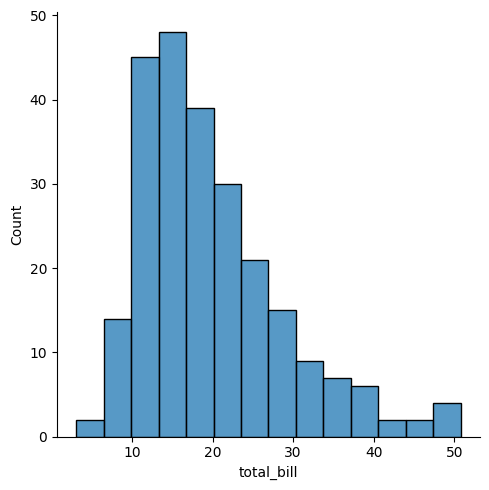

In [12]:
# We pass total_bill to x and df to data 
sns.displot(x='total_bill',data=df)
#alternative sns.histplot(x='total_bill',data=df)

**Interpretation:** *Most bills cluster between roughly 10–25, with a long right tail -  a handful of much larger bills (up to ~50) pull the distribution's average above its typical/median value.*

**Breaking down `sns.displot(x='total_bill', data=df)`:**

- **`sns`** -  the seaborn library (imported earlier as `import seaborn as sns`).
- **`displot`** -  short for "distribution plot." Seaborn's general-purpose function for visualizing how values of one variable are spread out (by default it draws a histogram).
- **`data=df`** -  tells seaborn *which dataframe* to pull the data from (here, the `tips` dataset).
- **`x='total_bill'`** -  tells seaborn *which column* to put on the x-axis. Since only `x` is given (no `y`), this is a **univariate** plot: seaborn counts how many rows fall into each bin of `total_bill` values and plots the counts as bars.

**What you should see:** a histogram where the x-axis is the bill amount ($) and the y-axis is the count of bills in each range -  helping us answer "what's a typical bill size, and are there any unusually high/low ones?"

**Try it yourself:**
- What happens if you swap to `y='total_bill'` instead of `x=`?
- What changes if you add `kind='kde'`?


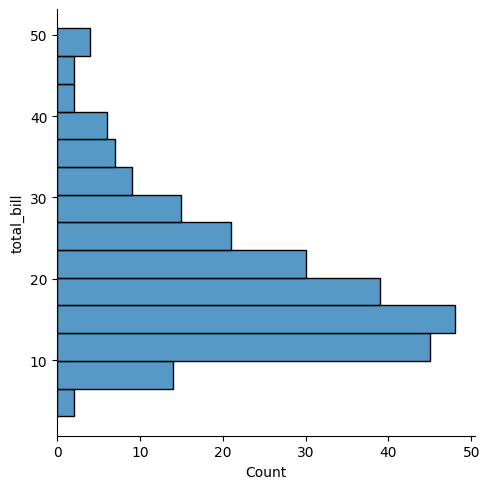

In [16]:
# What happens if you swap to y='total_bill' instead of x=?
sns.displot(y='total_bill',data=df)

## Task 2 -  Count plot

**Goal:** Display the frequency of each category.  
**Task:** Show how many observations exist for each day (`day`).  
**Hint:** Use `sns.countplot()` with `x='day'` and `data=df`.


<Axes: xlabel='day', ylabel='count'>

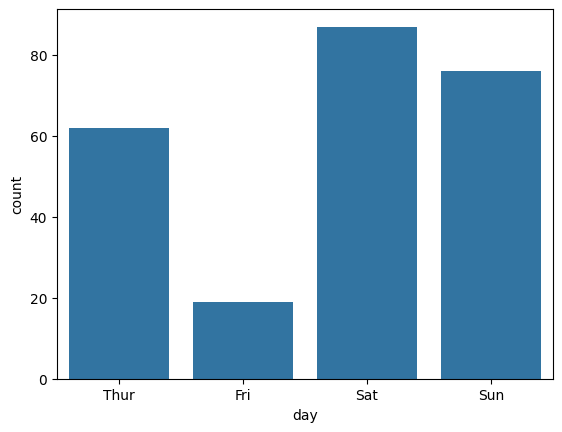

In [17]:
sns.countplot(x='day',data=df)

In [18]:
# just checking what data we have
df.head(2)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3


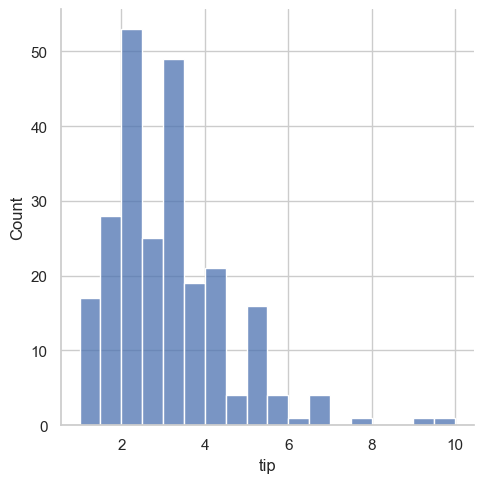

In [99]:
# What is the difference between the two
# sns.countplot(x='tip',data=df) # this would be unreadable 
# sns.displot(x='tip',data=df) #this uses range

**Interpretation:** *Saturday (87) and Sunday (76) together account for over two-thirds of the recorded visits, while Friday has by far the fewest (19) -  any day-by-day comparison should be read with that imbalance in mind.*

**Breaking down `sns.countplot(x='day', data=df)`:**

- **`countplot`** -  a categorical plot that counts how many rows fall into each category and shows the counts as bars. Unlike `displot`/`histplot` (which bin a *continuous* variable), `countplot` is built for variables that are already categories.
- **`data=df`** -  the dataframe to pull data from (the `tips` dataset).
- **`x='day'`** -  the categorical column to count. Seaborn automatically finds each unique value of `day` (Thur, Fri, Sat, Sun) and counts how many rows have that value.

**What you should see:** one bar per day, with height = number of visits recorded on that day.

**Try it yourself:**
- What happens if you swap to `y='day'` instead of `x=`?
- What changes if you add `hue='time'`?


In [100]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')

<Axes: xlabel='day', ylabel='count'>

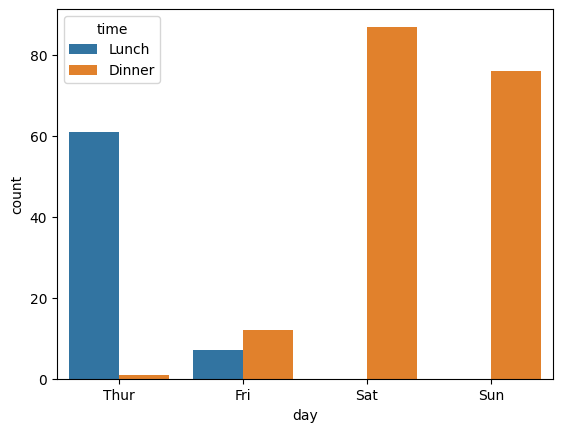

In [21]:
# sns.countplot(y='day',data=df)
sns.countplot(x='day',data=df,hue='time')

## Task 3 -  Scatter plot (bivariate: continuous vs continuous)

**Goal:** Visualize the relationship between two continuous variables.  
**Task:** Plot `total_bill` (x-axis) vs `tip` (y-axis).  
**Hint:** Use `sns.scatterplot()` and provide `x`, `y`, and `data=df`.


<Axes: xlabel='total_bill', ylabel='tip'>

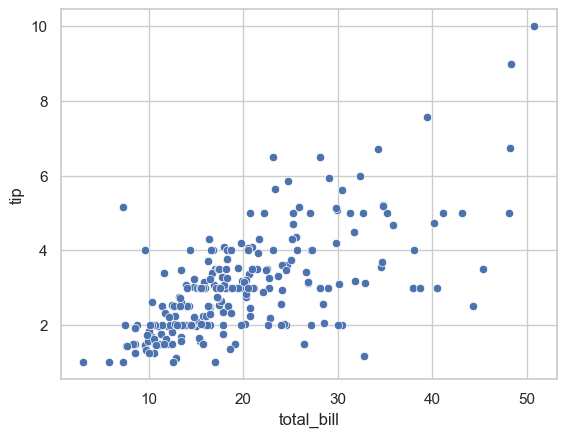

In [101]:
sns.scatterplot(x='total_bill',y='tip',data=df)

**Interpretation:** *The points trend clearly upward -  bigger bills come with bigger tips (correlation ≈ 0.68) -  though the spread around that trend shows tipping isn't a fixed percentage for everyone.*

**Breaking down `sns.scatterplot(x='total_bill', y='tip', data=df)`:**

- **`scatterplot`** -  a relational plot that shows each row as a single point, positioned by two continuous variables. Unlike `displot`/`countplot` (which summarize *one* variable), `scatterplot` shows the **relationship between two** variables at once.
- **`data=df`** -  the dataframe to pull data from (the `tips` dataset).
- **`x='total_bill'`** -  the column that sets each point's horizontal position.
- **`y='tip'`** -  the column that sets each point's vertical position.

Each dot on the plot = one table's visit: how much the bill was (x) and how much they tipped (y).

**What you should see:** a cloud of points that trends upward-ish -  bigger bills tend to come with bigger tips -  but with plenty of scatter/noise around that trend.

**Try it yourself:**
- What happens if you add `hue='sex'`?
- What does `size='size'` (party size) do to the points?
- How is this different from what `sns.regplot()` (Task 4) will add?


<Axes: xlabel='total_bill', ylabel='tip'>

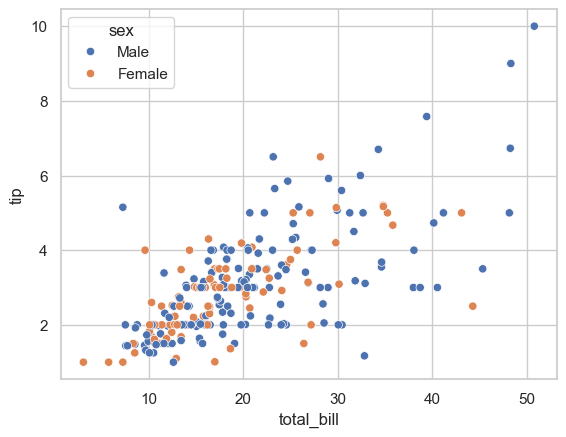

In [102]:
sns.scatterplot(x='total_bill',y='tip',data=df,hue='sex')

## Task 4 -  Regression plot

**Goal:** Add a regression line to help see trends.  
**Task:** Use `total_bill` and `tip` to show points + best-fit line.  
**Hint:** Try `sns.regplot()` (it adds the regression line automatically).


<Axes: xlabel='total_bill', ylabel='tip'>

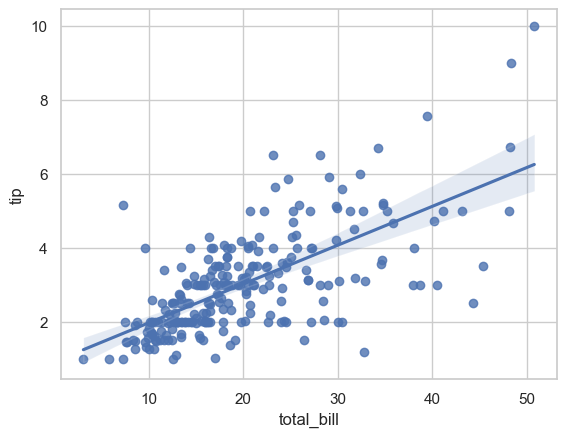

In [103]:
sns.regplot(x='total_bill',y='tip',data=df)

**Interpretation:** *The upward-sloping line confirms the trend from the scatterplot -  on average, a bigger bill comes with a bigger tip, though individual points still scatter noticeably around the line.*

**Breaking down `sns.regplot(x='total_bill', y='tip', data=df)`:**

- **`regplot`** -  short for "regression plot." It does everything `scatterplot` does (plots each row as a point using `x` and `y`), but also fits and draws a **best-fit line** (plus a shaded confidence band) through the points.
- **`data=df`** -  the dataframe to pull data from (the `tips` dataset).
- **`x='total_bill'`** -  the column on the horizontal axis (same as the scatterplot).
- **`y='tip'`** -  the column on the vertical axis (same as the scatterplot).

So this is the same scatter of points as Task 3, but with a line summarizing the overall trend added on top -  making it easier to say "yes, tip tends to go up as the bill goes up" without eyeballing the cloud of dots.

**What you should see:** the same total_bill-vs-tip scatter as before, now with a straight line sloping upward through it, and a shaded band around the line showing the uncertainty of that estimate.

**Try it yourself:**
- What does the shaded band around the line represent? (Hint: confidence interval)
- What happens if you add `order=2` -  does the line still look straight?
- Compare this to `sns.scatterplot()` -  when would you choose one over the other?

<Axes: xlabel='total_bill', ylabel='tip'>

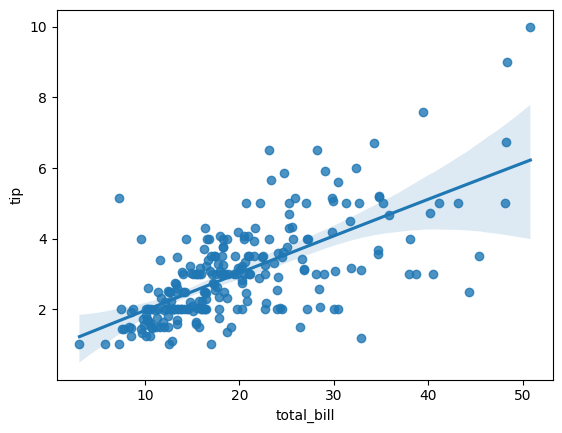

In [40]:
sns.regplot(x='total_bill',y='tip',data=df,order=2)

## Task 5 -  Bar plot (compare a continuous variable across categories)

**Goal:** Compare the **average tip** for each day.  
**Task:** Create a bar plot of mean `tip` for each `day`.  
**Hint:** Use `sns.barplot()` with `x='day'` and `y='tip'`.


<Axes: xlabel='day', ylabel='tip'>

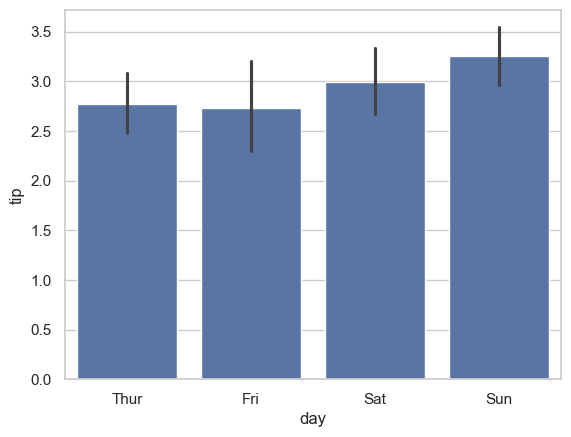

In [104]:
sns.barplot(x='day',y='tip',data=df)

**Interpretation:** *Average tips are fairly close across days (~$2.70–3.25), with Sunday highest and Friday lowest -  but Friday's average rests on only 19 visits, so it's the least reliable of the four.*

**Breaking down `sns.barplot(x='day', y='tip', data=df)`:**

- **`barplot`** -  a categorical plot that compares a **continuous** variable across groups of a **categorical** variable. For each category, it doesn't plot every row -  it computes a **summary statistic** (by default, the **mean**) and draws a bar at that height.
- **`data=df`** -  the dataframe to pull data from (the `tips` dataset).
- **`x='day'`** -  the categorical column that defines the groups (Thur, Fri, Sat, Sun) -  one bar per day.
- **`y='tip'`** -  the continuous column being summarized -  the height of each bar is the **average tip** for that day.
- The thin black line on top of each bar is the **error bar** -  by default a 95% confidence interval around that mean, similar in spirit to the shaded band in `regplot`.

This is a key contrast to `countplot` (Task 2): `countplot` counted *rows per category*, `barplot` summarizes *a numeric value per category*.

**What you should see:** four bars, one per day, with height = average tip on that day, and small error bars showing the uncertainty of that average.

**Try it yourself:**
- What happens if you add `hue='sex'`?
- What changes if you pass `estimator='median'` instead of the default mean?
- How is this different from a `violinplot` (Task 6), which we'll look at next?


<Axes: xlabel='day', ylabel='tip'>

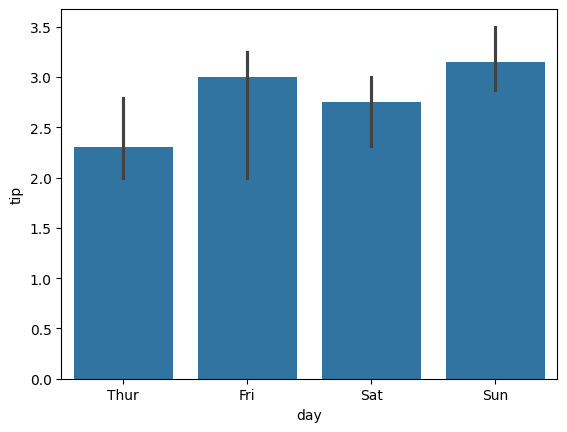

In [6]:
# sns.barplot(x='day',y='tip',data=df,hue='sex')
# sns.barplot(x='day',y='tip',data=df,estimator='median')

## Task 6 -  Violin plot (compare full distributions across categories)

**Goal:** Compare the full distribution (not just the mean) of `tip` for different days.  
**Task:** Create a violin plot of `tip` grouped by `day`.  
**Hint:** Use `sns.violinplot()` with `x='day'`, `y='tip'`.


<Axes: xlabel='day', ylabel='tip'>

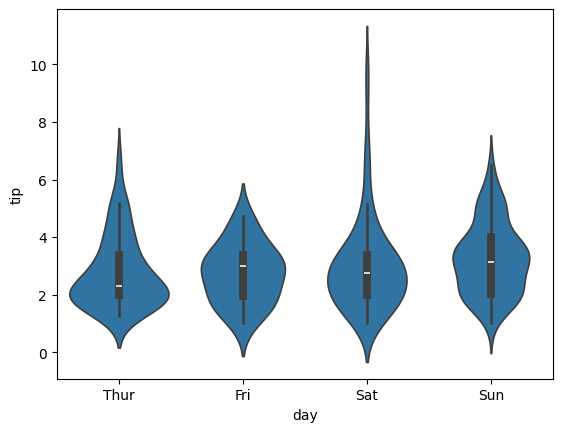

In [7]:
sns.violinplot(x='day',y='tip',data=df)

**How to read a violin plot:**

Each violin has four visual parts, from the outside in:
* **The overall shape (the "violin" outline)** — its width at any height shows how common tips of that amount were. A wide section means lots of visits landed around that tip amount; a narrow section means few did.
* **The thin black line stretching top to bottom** — the full range the tips reach for that day, from lowest to highest.
* **The thick black bar in the middle** — where the bulk (middle half) of the tips fall.
* **The white dot** — the median, the "typical" tip for that day. Higher dot means a higher typical tip.

**Interpretation:** * Sunday's white dot sits clearly higher than the other three, so a typical tip on Sunday is bigger than on any other day. Thursday's white dot sits lowest, so Thursday has the smallest typical tip. Friday's violin is short and stays narrow along almost its whole length, its tips are tightly bunched together with barely any long thin tail, meaning Friday's tipping is the most predictable, though it is also the thinnest violin overall, hinting there were fewer visits to draw that shape from. Saturday looks different from the rest: its thick middle section sits about as low as Thursday's, but a long, thin tail stretches far above all the other violins, all the way past 10. That tail is what makes Saturday stand out, a few visits tipped far more than usual, which pulls the shape upward even though a typical Saturday tip is not especially high. So the "best" day depends on what you care about: Sunday for the highest typical tip, Saturday for the chance of an unusually large one, and Friday for the most consistent (if less common) tipping.*



**Breaking down `sns.violinplot(x='day', y='tip', data=df)`:**

- **`violinplot`** -  a categorical plot that, like `barplot`, compares a **continuous** variable across groups. But instead of collapsing each group down to a single summary number (the mean), it shows the **full distribution** (shape) of the values in each group.
- **`data=df`** -  the dataframe to pull data from (the `tips` dataset).
- **`x='day'`** -  the categorical column that defines the groups -  one "violin" per day.
- **`y='tip'`** -  the continuous column whose distribution is drawn for each day.

Each violin is a mirrored, smoothed density curve (like a KDE) -  wider sections mean tip values are more common there, narrower sections mean they're rarer. Many versions also draw a mini box-plot (median + quartiles) inside the violin.

This is the natural next step up from `barplot`: `barplot` answers "what's the *average* tip per day?", while `violinplot` answers "what does the *whole spread* of tips look like per day -  is it skewed, are there two clusters, outliers, etc.?"

**What you should see:** four violin shapes, one per day, each showing where tip values cluster and how spread out or skewed they are.

**Try it yourself:**
- Compare this to the `barplot` from Task 5 -  does the day with the highest average tip also have the widest/most varied distribution?
- What happens if you add `hue='sex'` and `split=True`?
- Try `sns.boxplot()` on the same data -  how does it differ from the violin?


<Axes: xlabel='day', ylabel='tip'>

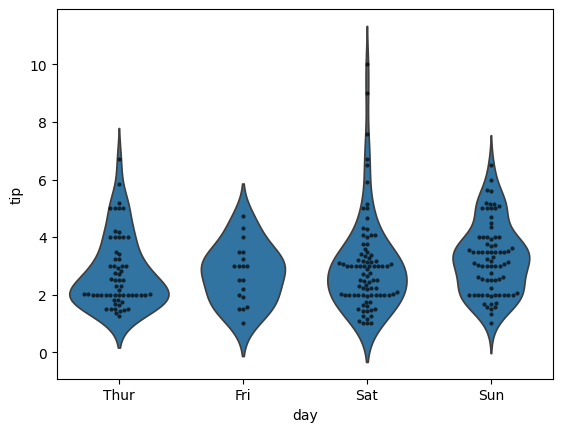

In [17]:
# sns.violinplot(x='day', y='tip', data=df, inner=None)  # inner=None removes the built-in mini boxplot so points aren't cluttered
# sns.swarmplot(x='day', y='tip', data=df, color='k', size=3, alpha=0.7)

**Showing the raw points behind the violin shape:**

- **`swarmplot()`** -  plots every individual point, nudging overlapping ones sideways so none stack on top of each other. Great for smaller datasets (few hundred points) -  it literally shows every observation that built the violin's shape.
- **`stripplot(..., jitter=True)`** -  similar, but instead of carefully avoiding overlap, it randomly jitters points sideways. Faster and scales better to larger datasets, but points can still overlap.
- We call both **after** `violinplot()` in the same cell (matplotlib draws them on the same axes, stacked on top) and set `inner=None` on the violin so its built-in box/points don't visually clash with the swarm.

**Why this matters for class:** it makes the abstraction concrete -  students can see that the "fat" part of the violin is fat *because* there's a dense cluster of real points there, not just a smoothing artifact.

**Try it yourself:**
- Remove `inner=None` -  what does the violin's built-in inner marking look like compared to the swarm?
- Try `swarmplot()` alone (without the violin) -  how much does the violin's smoothed shape actually add?


In [11]:
# sns.violinplot(x='day',y='tip',data=df,hue='sex',split=True)

## Task 7 - Extra practice: add `hue`, `col`, and `style`

Try one or more:
- Add `hue='sex'` to the scatter plot
- Use `col='time'` with `sns.displot()` to compare lunch vs dinner
- Use `style='sex'` with `sns.scatterplot()`


# Data preparation and visualisation

By the end of the tutorials of this week, you should acquire:

**Knowledge on:**
* Using basic Natural Language Processing 
* Considerations about unit of analysis
* Descriptive exploration of data to answer RQ
* Applying univariate and bivariate visualization (practiced earlier) to a real research dataset
* Reporting and interpretation

**Skills:**
* .apply() and selection of functions based on existing list
* .drop_duplicates()
* Using Seaborn 
* Choosing the appropriate chart for visualizations
* Interpreting visualizations and descriptives

### What we analyze today?

We will explore the following research questions:
* RQ1. To what extent does the sentiment expressed in the title of the video influence user engagement (views, likes and dislikes)?
* RQ3. To what extent does the sentiment expressed in the title of the video vary depending on whether Joe Biden is mentioned in the video?
* RQ3a. To what extent the category of the video is related to mentions of Joe Biden in the video?

To answer these, we still need to prepare two things in the data:
* A variable indicating whether Joe Biden is mentioned in a video (not yet in the dataset -  we'll create it below)
* An overall sentiment score for each video title (computed from the existing positive/negative sentiment columns)

### One more display setting

We already have `pandas`, `seaborn`, and inline plotting set up from earlier in this notebook.  The only new thing below is telling pandas to format floating-point numbers to 3 decimal places when displaying dataframes, which makes tables of statistics easier to read.

In [171]:
# New here: format floats to 3 decimal places when displaying dataframes
pd.set_option('display.float_format', lambda x: '%.3f' % x)

### Loading the data
Let's now load the data we worked with last week.

In [105]:
# !ls

In [106]:
videos = pd.read_pickle('da4_data/videos_sent.pkl')

In [107]:
len(videos) #368

368

In [163]:
# lets check the what columns we have
videos.columns

Index(['position', 'channelId', 'channelTitle', 'videoId', 'publishedAt',
       'publishedAtSQL', 'videoTitle', 'videoDescription', 'tags',
       'videoCategoryId', 'videoCategoryLabel', 'duration', 'durationSec',
       'dimension', 'definition', 'caption', 'thumbnail_maxres',
       'licensedContent', 'viewCount', 'likeCount', 'dislikeCount',
       'favoriteCount', 'commentCount', 'dislikeCount_no_na', 'lang_title',
       'negative', 'positive', 'neutral', 'category', 'biden_tag',
       'biden_title', 'biden_description', 'biden_mentioned',
       'sentiment_overall'],
      dtype='str')

### Unit of analysis
Our unit for analysis is for our research question is a video. We are interested in relations between charactertistics of the title and engagement the video generates. Not to inflate the relation, we need to make sure that each video is only once in my dataset.

In [109]:
videos['videoId'].value_counts()

videoId
NIDEvBH8QXM    4
EuwMB1Dal-4    4
0sNP5jgDa_g    4
UcdgDbMpS5Q    4
xkgt1Avnvw0    1
              ..
1NBQZkySDY0    1
w3VUI3K2n5o    1
7vOwjNTDwBE    1
ZwyEW_rDeqQ    1
G9AxUZwENfc    1
Name: count, Length: 356, dtype: int64

**Breaking down `videos['videoId'].value_counts()`:**

- **`videos['videoId']`** -  selects just the `videoId` column (a Series) out of the `videos` dataframe.
- **`.value_counts()`** -  counts how many times each unique value appears in that column, and returns them sorted from most frequent to least frequent.

**Why we're doing this:** our unit of analysis is *one video* -  we want to study the relationship between title characteristics and engagement, one row per video. But this dataset might contain the same video more than once (e.g., pulled from multiple search queries or scraped twice). `.value_counts()` lets us check: are there any `videoId`s appearing 2+ times?

**What you should see:** a list of videoIds with counts -  most showing `1`, but if any show `2` or more, that's a duplicate video we need to deal with before analyzing.

**Try it yourself:**
- Add `.value_counts().max()` -  what's the highest count? Is it exactly 1 (no duplicates) or more?
- What does `(videos['videoId'].value_counts() > 1).sum()` tell you?


In [31]:
# filters the dataframe down to just the rows matching that specific `videoId`, 
# so we can inspect the duplicate rows side by side.
videos.loc[videos['videoId'] == 'NIDEvBH8QXM']

,position,channelId,channelTitle,videoId,publishedAt,publishedAtSQL,videoTitle,videoDescription,tags,videoCategoryId,...,likeCount,dislikeCount,favoriteCount,commentCount,dislikeCount_no_na,lang_title,negative,positive,neutral,category
325,346,UCeY0bbntWzzVIaj2z3QigXg,NBC News,NIDEvBH8QXM,2021-04-20 12:59:47+00:00,2021-04-20 12:59:47,Experimental Air Capture Technology In Iceland...,According to the National Oceanic and Atmosphe...,"NBC News NOW,Deep Dives,NBC News Climate in Cr...",25,...,145.0,9.0,0,74.0,9.0,en,-1,1,0,News & Politics
326,346,UCeY0bbntWzzVIaj2z3QigXg,NBC News,NIDEvBH8QXM,2021-04-20 12:59:47+00:00,2021-04-20 12:59:47,Experimental Air Capture Technology In Iceland...,According to the National Oceanic and Atmosphe...,"NBC News NOW,Deep Dives,NBC News Climate in Cr...",25,...,145.0,9.0,0,74.0,9.0,en,-1,1,0,News & Politics
334,351,UCeY0bbntWzzVIaj2z3QigXg,NBC News,NIDEvBH8QXM,2021-04-20 12:59:47+00:00,2021-04-20 12:59:47,Experimental Air Capture Technology In Iceland...,According to the National Oceanic and Atmosphe...,"NBC News NOW,Deep Dives,NBC News Climate in Cr...",25,...,145.0,9.0,0,74.0,9.0,en,-1,1,0,News & Politics
335,351,UCeY0bbntWzzVIaj2z3QigXg,NBC News,NIDEvBH8QXM,2021-04-20 12:59:47+00:00,2021-04-20 12:59:47,Experimental Air Capture Technology In Iceland...,According to the National Oceanic and Atmosphe...,"NBC News NOW,Deep Dives,NBC News Climate in Cr...",25,...,145.0,9.0,0,74.0,9.0,en,-1,1,0,News & Politics


In [165]:
videos = videos.drop_duplicates(subset ="videoId",
                     ignore_index=True)

**Breaking down `videos.drop_duplicates(subset="videoId", ignore_index=True)`:**

- **`.drop_duplicates()`** -  a pandas method that removes duplicate rows from a dataframe. By default it compares **entire rows**: a row only counts as a duplicate if *every column* matches another row exactly.
- **`subset="videoId"`** -  narrows that comparison down to just the `videoId` column. This is important here: we don't need every column to match -  if two rows share the same `videoId`, that's the same video, even if other columns (like a scrape timestamp or slightly different view count) differ slightly. `subset` tells pandas "judge duplicates by this column only."
- **`ignore_index=True`** -  after dropping rows, the dataframe's index would normally keep gaps where rows were removed (e.g., 0, 1, 3, 4, 7...). This resets the index to a clean, sequential 0, 1, 2, 3... so there are no gaps left over.
- By default, `.drop_duplicates()` keeps the **first** occurrence of each duplicate and drops the rest (controlled by the `keep=` parameter, default `keep='first'`).
- **`videos = videos.drop_duplicates(...)`** -  this reassigns the result back to `videos`. `.drop_duplicates()` doesn't modify the dataframe in place by default -  it returns a *new* dataframe, so without the reassignment the duplicates would still be there.

**Why we're doing this:** our unit of analysis is one row per video. If the same video appears twice, any statistic we compute (means, correlations, counts) would over-count that video and bias our results -  this line enforces "one video, one row" before we do any analysis.

**What you should see:** `len(videos)` dropping from its earlier count (368) down to a smaller number (356) -  the difference being how many duplicate rows were removed.

**Try it yourself:**
- What would happen if you left out `subset="videoId"`? Would it still catch these duplicates? (Hint: check whether the duplicate rows were *fully* identical across all columns.)
- Try `keep='last'` instead of the default -  does it matter which duplicate is kept here?


In [166]:
len(videos) #356

356

### Data cleaning and preparation

The file has 
* all the information on a video (title, views, likes, dislikes), 
* raw sentiment scores (positive/negative) for the title.
* category variable created last week.

Two things still need to be prepared before we can explore our RQs:
* A binary variable marking whether Joe Biden is mentioned in the video (created just below)
* A combined `sentiment_overall` score from the raw positive/negative columns (created further below, in the "Sentiment" section)

#### Creating a new binary variable

In [129]:
import string

def wordlist_any_present(text, query):
    # Make sure text is a string, and lowercase it so matching isn't case-sensitive
    text = str(text).lower()
    
    # Lowercase each word we are searching for too
    normalized_query = []
    for word in query:
        normalized_query.append(str(word).lower())
        
    # Split the text into words, and strip punctuation from each one
    # (e.g. "biden," becomes "biden")
    words = []
    for word in text.split():
        words.append(word.strip(string.punctuation))

    # Check each query word one at a time. If we find it in the text, we're done.
    for word in normalized_query:
        if word in words:
            return 1
    # If we never found a match, return 0
    return 0

In [130]:
#Testing the function
wordlist_any_present("This is a text", ["text", "texts"])

1

In [168]:
videos['biden_tag'] = videos['tags'].apply(wordlist_any_present, args=(['biden', 'joe'],)) 

In [132]:
videos['biden_title'] = videos['videoTitle'].apply(wordlist_any_present, args=(['biden', 'joe'],)) 

In [133]:
videos['biden_description'] = videos['videoDescription'].apply(wordlist_any_present, args=(['biden', 'joe'],)) 

In [135]:
videos['biden_title'].value_counts()

biden_title
0    347
1     21
Name: count, dtype: int64

In [136]:
videos['biden_tag'].value_counts()

biden_tag
0    359
1      9
Name: count, dtype: int64

In [137]:
videos['biden_description'].value_counts()

biden_description
0    331
1     37
Name: count, dtype: int64

In [125]:
# # reset 
# videos['biden_mentioned'] = '0'
# videos['biden_mentioned'].value_counts()

biden_mentioned
0    368
Name: count, dtype: int64

In [138]:
# Mark biden_mentioned as 1 if ANY of the three flag columns is 1, else 0
videos['biden_mentioned'] = (
    (videos['biden_tag'] == 1) | (videos['biden_title'] == 1) | (videos['biden_description'] == 1)
).astype(int)

In [60]:
# videos = videos.apply(categorise_df, axis=1) - too complex

In [139]:
videos['biden_mentioned'].value_counts()

biden_mentioned
0    326
1     42
Name: count, dtype: int64

#### Sentiment

In [140]:
# Convert the 'positive' sentiment column from text to real numbers so we can do math with it
videos['positive'] = videos['positive'].apply(pd.to_numeric)

# Do the same for the 'negative' sentiment column
videos['negative'] = videos['negative'].apply(pd.to_numeric)

# Combine both into one overall sentiment score for each video title
videos['sentiment_overall'] = videos['negative'] + videos['positive']

**Breaking down `videos['positive'] = videos['positive'].apply(pd.to_numeric)`:**

- **`videos['positive']`** -  selects the `positive` column (a Series) from the dataframe.
- **`.apply(pd.to_numeric)`** -  applies pandas' `to_numeric` function to every value in that column, converting it from whatever type it currently is (often a string, e.g. `"0.42"`) into an actual numeric type (int or float).
- **`videos['positive'] = ...`** -  overwrites the column with the converted numeric version.

**Why we're doing this:** when data comes from a pickle/JSON file (as ours did, loaded last week), numeric-looking values sometimes get stored as **text** rather than real numbers -  e.g. `"0.42"` instead of `0.42`. Pandas can't do math on text: `"0.3" + "0.1"` would concatenate the strings into `"0.30.1"` instead of adding them to get `0.4`. We need `positive` and `negative` to be true numbers *before* we can combine them into `sentiment_overall` a few cells down.

**How to check if this was actually necessary:** run `videos['positive'].dtype` (or `videos.dtypes`) *before* this line -  if it shows `object` (pandas' generic "could be anything, often text" type), the conversion is needed. After running this line, it should show `float64` or `int64`.

**What you should see:** no visible output from this cell (it just reassigns the column), but if you check `videos['positive'].dtype` afterward, it should now be numeric.

**Try it yourself:**
- Run `videos.dtypes` before and after this cell -  which other columns might also secretly be stored as text and need the same treatment?
- What would `pd.to_numeric()` do if one of the values was something non-numeric, like `"n/a"`? (Hint: look up the `errors=` parameter -  `'raise'`, `'coerce'`, `'ignore'`.)


## Data Exploration and RQs

After all the data cleaning is done, you can see how the data finally look like, and report this to the stakeholders reading your report. It is important that:
* You provide enough information so that the stakeholder understands how the important variables look like
* You provide **only** the relevant information, to prevent *confusing* the stakeholder
* You provide explanations in MarkDown, including (a) the definition of the variables and (b) the interpretation of the exploration.

As outlined earlier, we'll focus on RQ1, RQ3, and RQ3a for this example -  now that the data is cleaned, we can explore the variables that answer them.

### Let's first consider the variables we have in the RQs:
* Sentiment: interval (or continuous)
* Views: continuous
* Likes: continuous
* Dislikes: continous
* Category of the video: categorical (multiple options)
* Mentions to Biden: binary (dichotomous)

This influences how we describe the variables, and how we visualize them (alone, and combined)

In [170]:
list(videos.columns)
# videos.columns

['position',
 'channelId',
 'channelTitle',
 'videoId',
 'publishedAt',
 'publishedAtSQL',
 'videoTitle',
 'videoDescription',
 'tags',
 'videoCategoryId',
 'videoCategoryLabel',
 'duration',
 'durationSec',
 'dimension',
 'definition',
 'caption',
 'thumbnail_maxres',
 'licensedContent',
 'viewCount',
 'likeCount',
 'dislikeCount',
 'favoriteCount',
 'commentCount',
 'dislikeCount_no_na',
 'lang_title',
 'negative',
 'positive',
 'neutral',
 'category',
 'biden_tag',
 'biden_title',
 'biden_description',
 'biden_mentioned',
 'sentiment_overall']

In [142]:
len(videos)

368

In [172]:
videos[['sentiment_overall', 'viewCount', 'likeCount', 'dislikeCount']].describe()

,sentiment_overall,viewCount,likeCount,dislikeCount
count,356.000,356.000,356.000,356.000
mean,-0.354,181912.576,4477.382,429.388
std,0.861,718361.132,19526.898,2666.917
min,-4.000,0.000,0.000,0.000
25%,0.000,2245.250,54.750,8.000
50%,0.000,15707.000,262.000,51.000
75%,0.000,81258.000,1638.500,165.000
max,2.000,7435424.000,267054.000,45290.000


**Breaking down `videos[['sentiment_overall', 'viewCount', 'likeCount', 'dislikeCount']].describe()`:**

- **`videos[[...]]`** -  double square brackets select **multiple columns** at once (a list of column names), returning a smaller dataframe with just those four columns. (Single brackets `videos['col']` would return one column as a Series; double brackets keep it a DataFrame.)
- **`.describe()`** -  a pandas method that computes summary statistics for each numeric column: count, mean, std (standard deviation), min, 25%/50%/75% percentiles, and max.
- The Xth percentile is the value that X% of your data falls below, so a 75th percentile of 81,258 views means 75% of videos have fewer than 81,258 views.

**Why we're doing this:** these four columns are exactly the continuous variables involved in our RQs (sentiment, views, likes, dislikes). Before visualizing or modeling anything, we want a quick numeric snapshot: what's the typical value, how spread out are the values, are there extreme outliers (e.g., a max view count way higher than the 75th percentile)?

**What you should see:** a small table with one row per statistic and one column per variable -  letting you compare, for example, the average `sentiment_overall` against its spread, or spot that `viewCount` likely has a much larger range than `likeCount`.

**Try it yourself:**
- Why did we select just these four columns instead of running `.describe()` on the whole `videos` dataframe? (Hint: what would happen with non-numeric columns like `category` or `videoTitle`?)
- Look at the `min` and `max` for `viewCount` -  does anything stand out as unusually large or small?


In [144]:
videos['biden_mentioned'].value_counts(normalize=True)

biden_mentioned
0    0.88587
1    0.11413
Name: proportion, dtype: float64

In [ ]:
# Count of '0' divided by the total numberof row
# 308/(48+308), 48/(48+308)

In [145]:
videos['category'].value_counts(normalize=True)

category
News & Politics                      0.597826
Other                                0.184783
Education, Science and Technology    0.176630
Nonprofits & Activism                0.040761
Name: proportion, dtype: float64

In [174]:
# videos.groupby(['biden_mentioned']).describe()
videos.groupby(['biden_mentioned'])['sentiment_overall'].describe()

,count,mean,std,min,25%,50%,75%,max
biden_mentioned,,,,,,,,
0,317.000,-0.363,0.848,-4.000,0.000,0.000,0.000,2.000
1,39.000,-0.282,0.972,-4.000,0.000,0.000,0.000,1.000


**Breaking down `videos.groupby(['biden_mentioned'])['sentiment_overall'].describe()`:**

- **`videos.groupby(['biden_mentioned'])`** -  splits the dataframe into separate groups based on the values in `biden_mentioned` (here, two groups: rows where it's `0`, and rows where it's `1`).
- **`['sentiment_overall']`** -  from each of those groups, selects just the `sentiment_overall` column -  we only care about summarizing this one variable per group.
- **`.describe()`** -  computes the same summary statistics as before (count, mean, std, min, 25/50/75%, max), but now **separately for each group** instead of for the whole dataset at once.

This is the same `.describe()` we used earlier on the whole dataset -  the only new part is `.groupby()`, which lets us ask "does this statistic look different depending on category?" instead of just "what does this look like overall?"

**Why we're doing this:** this directly answers RQ3 -  "does sentiment vary depending on whether Biden is mentioned?" By comparing the `mean` (and spread) of `sentiment_overall` between the `biden_mentioned=0` group and the `biden_mentioned=1` group, we get a first numeric hint at whether there's a difference, *before* we visualize it with `violinplot`/`barplot` later.

**What you should see:** two rows of statistics -  one for videos that don't mention Biden, one for videos that do -  letting you compare their average sentiment side by side.

**Try it yourself:**
- Just from the `mean` values, does one group look like it has higher sentiment than the other?
- What does `videos.groupby(['category', 'biden_mentioned'])['sentiment_overall'].describe()` (used two cells later) add on top of this?


In [70]:
videos.groupby(['category', 'biden_mentioned'])['sentiment_overall'].describe()

count      mean       std  \
category                          biden_mentioned                              
Education, Science and Technology 0                 65.0 -0.169231  0.697523   
News & Politics                   0                180.0 -0.444444  0.860182   
                                  1                 40.0 -0.275000  0.960435   
Nonprofits & Activism             0                 15.0 -0.800000  1.014185   
Other                             0                 66.0 -0.181818  0.802095   
                                  1                  2.0  0.000000  0.000000   

                                                   min  25%  50%  75%  max  
category                          biden_mentioned                           
Education, Science and Technology 0               -3.0  0.0  0.0  0.0  1.0  
News & Politics                   0               -4.0 -1.0  0.0  0.0  2.0  
                                  1               -4.0  0.0  0.0  0.0  1.0  
Nonprofits & Activism             0               -2.0 -2.0  0.0  0.0  0.0  
Other                             0               -3.0  0.0  0.0  0.0  2.0  
                                  1                0.0  0.0  0.0  0.0  0.0

**Breaking down `videos.groupby(['category', 'biden_mentioned'])['sentiment_overall'].describe()`:**

- **`videos.groupby(['category', 'biden_mentioned'])`** -  same idea as before, but now grouping by **two** columns instead of one. Pandas creates one group for every *combination* of `category` and `biden_mentioned` (e.g., "News + mentions Biden", "News + doesn't mention Biden", "Entertainment + mentions Biden", ...).
- **`['sentiment_overall']`** -  again, selects just the sentiment column to summarize within each of those combined groups.
- **`.describe()`** -  same summary statistics as before, computed separately for every category × biden_mentioned combination.

This builds directly on the previous cell: instead of asking "does sentiment differ by Biden mention?" (one grouping variable), we're now asking a more detailed question involving both grouping variables at once.

**Why we're doing this:** this is a finer-grained look that touches on RQ3a -  it lets us see whether the sentiment difference between mentioning/not-mentioning Biden **holds consistently across every video category**, or whether it's really only driven by one or two categories (e.g., maybe "Politics" videos show a big gap, but "Music" videos show almost none).

**What you should see:** a table with one row per category/biden_mentioned combination -  more rows than the previous cell, since it's now split two ways instead of one. Some combinations may have very small `count` values (few videos in that specific combination), which affects how much you should trust their mean.

**Try it yourself:**
- Look at the `count` column -  are any category/biden_mentioned combinations based on very few videos? How does that affect how confident you'd be in their average sentiment?
- How does this two-variable grouping connect to the `sns.barplot(x='category', y='biden_mentioned', data=videos)` cell coming up later (RQ3a)?


## Visualizations

For every variable in a RQ (i.e., a key variable), we need to create (and interpret) a univariate visualisation. We'll use the seaborn package for this -  the same `data`/`x`/`y`/`hue`/`col`/`style` grammar we practiced earlier, now applied to a real research dataset.

### Types of visualizations

We can distinguish between univariate and bivariate plots. Univariate plots visualize one variable, while bivariate plots show the relation between variables.

Looking at seaborn options, we can distinguish
* Relational plots - that show a relation between two continous variables
* Distribution plots - that show distributions of continous variables
* Categorical plots - that show distributions of categorical variables. 

### Univariate visualizations

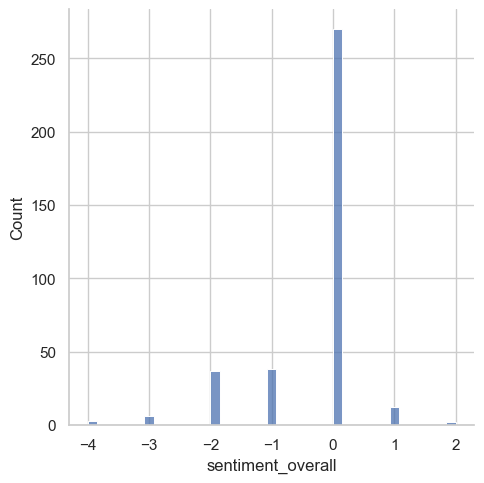

In [149]:
#Distribution of continous variables
sns.displot(x = 'sentiment_overall', data = videos)

**Interpretation:** *Most videos should cluster around a similar sentiment level, with fewer videos at the extremes -  check whether the distribution looks roughly symmetric (balanced positive/negative) or skewed toward one side.*

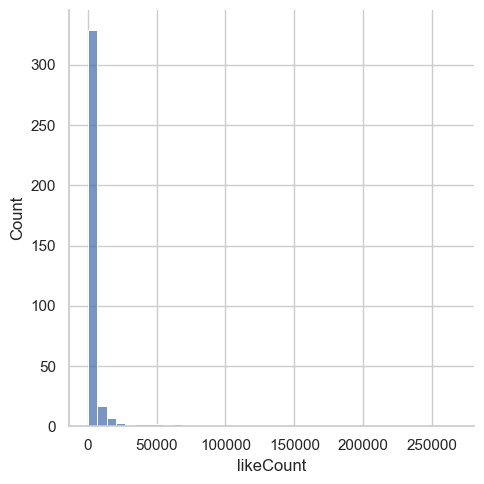

In [150]:
sns.displot(x = 'likeCount', data = videos)

**Interpretation:** *If most bars pile up near zero with a long tail stretching right, that means a few videos get disproportionately more likes than the rest -  a common pattern for engagement metrics.*

<Axes: xlabel='biden_mentioned', ylabel='count'>

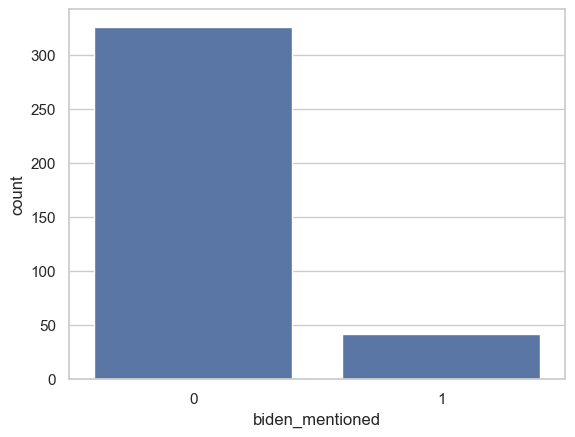

In [151]:
#Distribution of categorical variable
sns.countplot(x = 'biden_mentioned', data=videos)

**Interpretation:** *The bar for "not mentioned" (308 videos) towers over "mentioned" (48 videos) -  only about 1 in 7 videos in this dataset mentions Biden, so any comparison between the two groups should be read with that imbalance in mind.*

([0, 1, 2, 3],
 [Text(0, 0, 'Other'),
  Text(1, 0, 'News & Politics'),
  Text(2, 0, 'Education, Science and Technology'),
  Text(3, 0, 'Nonprofits & Activism')])

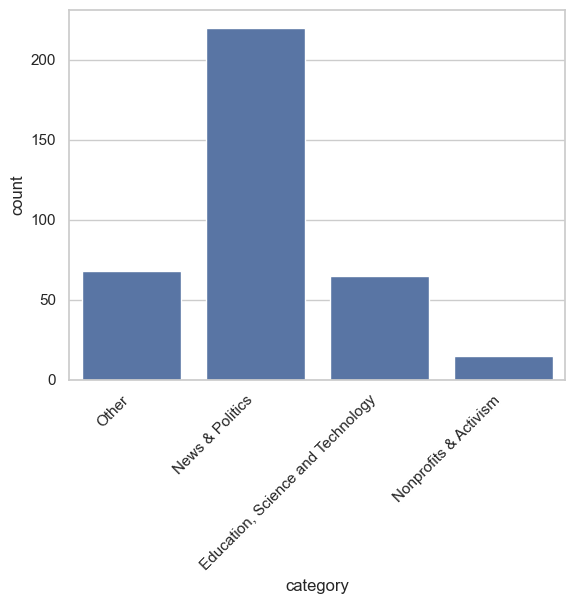

In [159]:
sns.countplot(x='category', data=videos)
# For readablity
# plt.xticks(rotation=45, ha='right')  # ha='right' keeps the label ends aligned under their bar

**Interpretation:** *Whichever bar is tallest is the most common video category in the dataset -  worth noting if one category dominates, since that could drive patterns we see later when we split other variables by category.*

<Axes: xlabel='count', ylabel='category'>

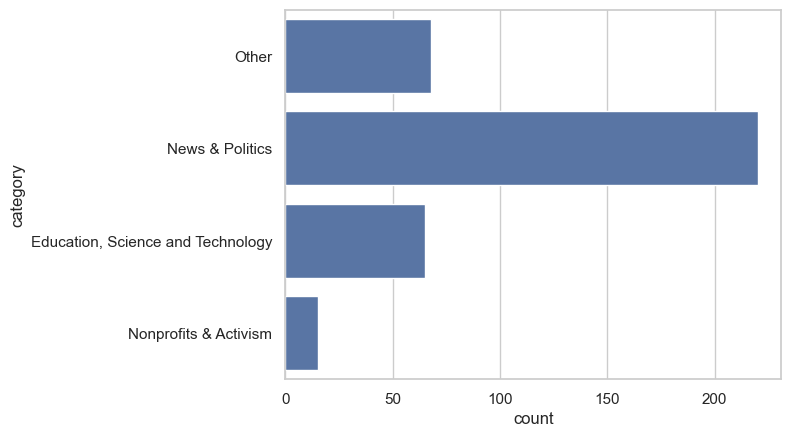

In [78]:
# You can also flip the plot for more visibility
# sns.countplot(y='category', data=videos)

### Bivariate visualizations

RQ1. To what extent does the sentiment expressed in the title of the video influence user engagement (views, likes and dislikes)?

<Axes: xlabel='sentiment_overall', ylabel='viewCount'>

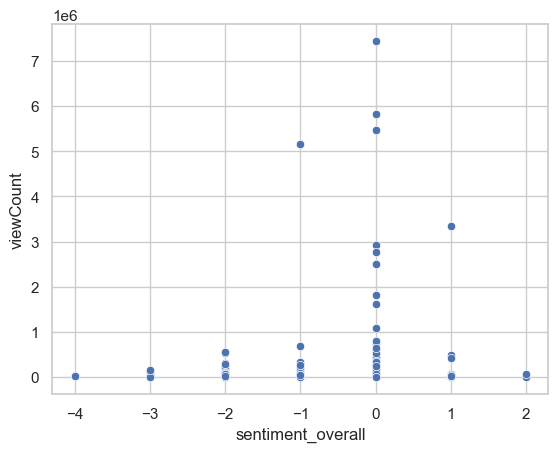

In [175]:
#Relation between two continous variables
sns.scatterplot(x='sentiment_overall', y='viewCount', data=videos)

**Interpretation:** *If the points show no clear upward or downward slope, that's a first hint that title sentiment alone doesn't strongly predict how many views a video gets.*

<Axes: xlabel='sentiment_overall', ylabel='likeCount'>

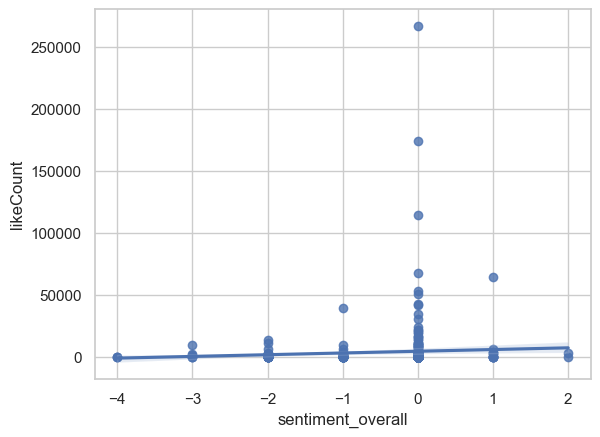

In [153]:
sns.regplot(x='sentiment_overall', y='likeCount', data=videos)

**Interpretation:** *A regression line sloping upward would suggest more positive titles tend to get more likes -  the flatter the line, the weaker that relationship.*

<Axes: xlabel='sentiment_overall', ylabel='dislikeCount'>

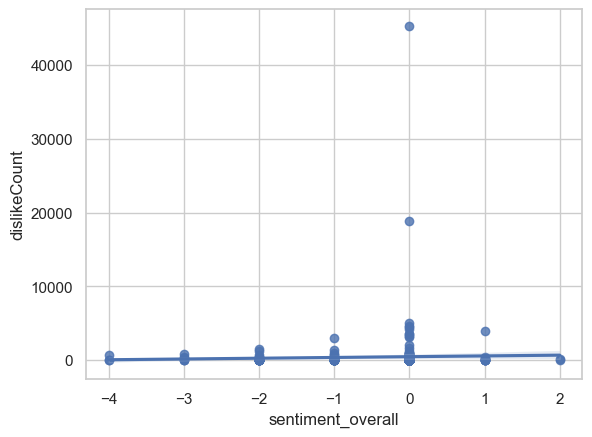

In [176]:
sns.regplot(x='sentiment_overall', y='dislikeCount', data=videos)

**Interpretation:** *Compare this line's slope to the one for likes above -  if dislikes rise where likes also rise, sentiment may be linked more to overall engagement than to positive reception specifically.*

RQ3. To what extent does the sentiment expressed in the title of the video vary depending on whether Joe Biden is mentioned?

<Axes: xlabel='biden_mentioned', ylabel='sentiment_overall'>

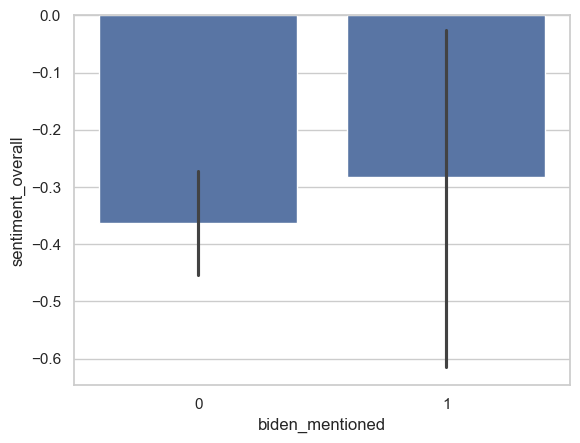

In [177]:
#Relation between a categorical variable and a continous variable
sns.barplot(x='biden_mentioned', y='sentiment_overall', data=videos)

**Interpretation:** *If the two bars are close in height, mentioning Biden doesn't seem to coincide with a meaningfully different average title sentiment -  the more the bars (and their error bars) differ, the stronger that signal.*

<Axes: xlabel='biden_mentioned', ylabel='sentiment_overall'>

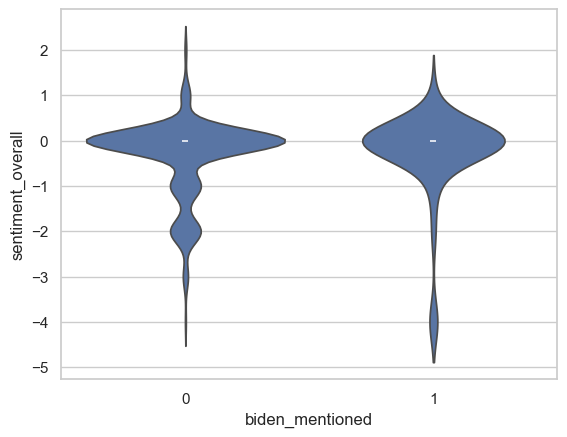

In [156]:
sns.violinplot(x='biden_mentioned', y='sentiment_overall', data=videos)

**Interpretation:** *Beyond just comparing averages (as the barplot did), check whether one violin is wider/more spread out than the other -  that would mean sentiment is more variable within that group, not just shifted higher or lower.*

RQ3a. To what extent the category of the video is related to mentions of Joe Biden on the title?

([0, 1, 2, 3],
 [Text(0, 0, 'Other'),
  Text(1, 0, 'News & Politics'),
  Text(2, 0, 'Education, Science and Technology'),
  Text(3, 0, 'Nonprofits & Activism')])

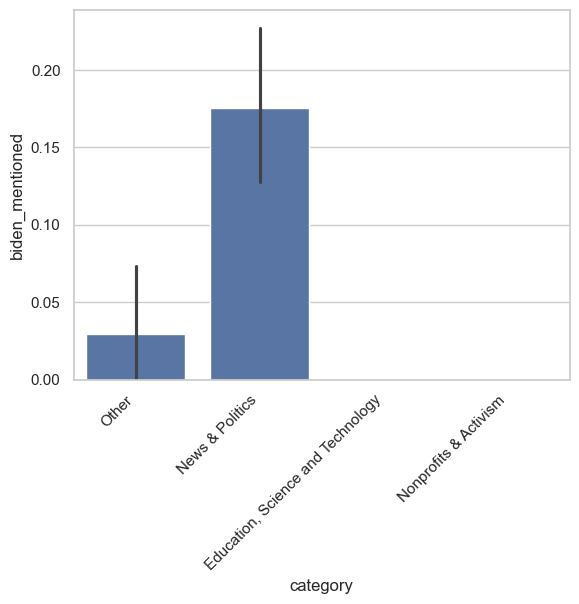

In [180]:
#Relation between a categorical variable and a continous variable
sns.barplot(x='category', y='biden_mentioned', data=videos)
# sns.barplot(y='category', x='biden_mentioned', data=videos) #option1 for readablity
plt.xticks(rotation=45, ha='right')  # ha='right' keeps the label ends aligned under their bar

**Interpretation:** *Taller bars mean a larger share of that category's videos mention Biden -  a good next step is checking whether that lines up with which categories are more "political" in nature.*

<Axes: xlabel='biden_mentioned', ylabel='category'>

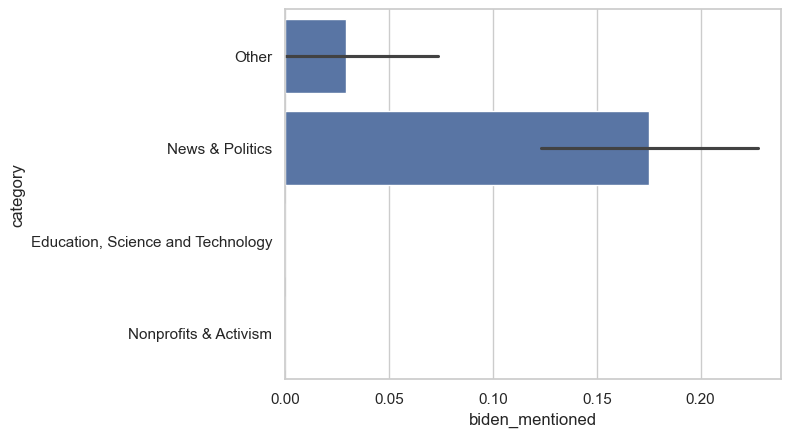

In [178]:
sns.barplot(y='category', x='biden_mentioned', data=videos)

**Interpretation:** *Same relationship as above, just rotated -  useful when category names are long and hard to read stacked vertically on the x-axis.*

We can also include more than two variables in a graph. Options such as `hue` allow us to do so.

<Axes: xlabel='sentiment_overall', ylabel='viewCount'>

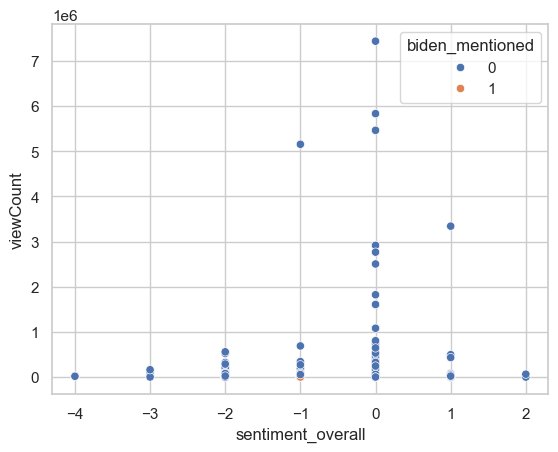

In [86]:
#Relation between two continous variables split by a binary variable
sns.scatterplot(x='sentiment_overall', y='viewCount', hue = 'biden_mentioned', data=videos)

**Interpretation:** *Color-coding by `biden_mentioned` lets us check whether the sentiment–views relationship looks different for the two groups -  e.g., if one color's points trend differently than the other's.*

### Bonus: customizing themes and palettes

The great advantage of seaborn is that it easily allows you to add variables, change styles, looks etc. Below, there are some examples how you can set a theme or change color palette. The website of seaborn includes a [gallery](https://seaborn.pydata.org/examples/index.html) that you can use for inspiration. Make sure to follow the basic grammar and experiment to add different elements and change styles.

<Axes: xlabel='biden_mentioned', ylabel='count'>

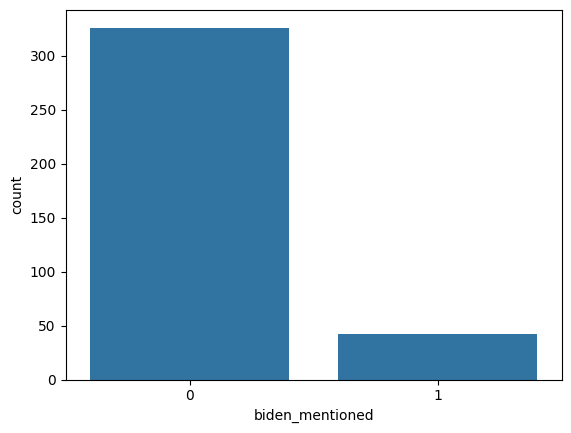

In [71]:
sns.countplot(x = 'biden_mentioned', data=videos)

<Axes: xlabel='biden_mentioned', ylabel='count'>

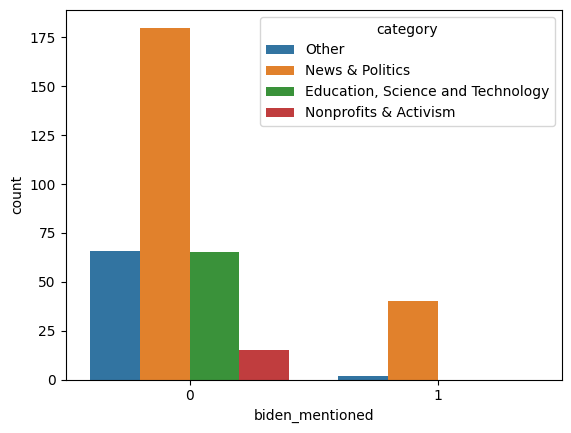

In [72]:
sns.countplot(x = 'biden_mentioned', hue='category', data=videos)

/var/folders/y_/81kq7b1d6v186rxnhwbtxybm0000gn/T/ipykernel_4833/310195446.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'biden_mentioned', data=videos, palette="dark")


<Axes: xlabel='biden_mentioned', ylabel='count'>

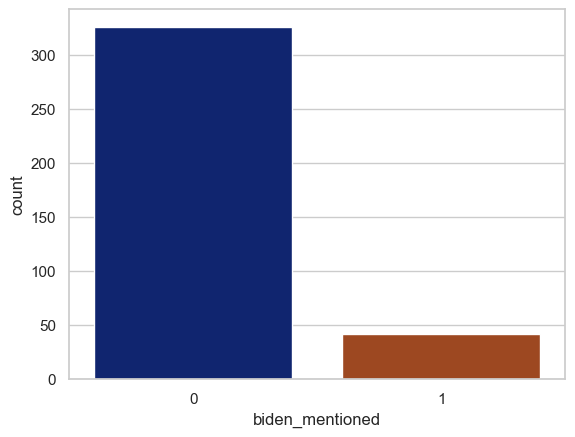

In [73]:
sns.set_theme(style="whitegrid")
sns.countplot(x = 'biden_mentioned', data=videos, palette="dark")